# Mental Health Sentiment Classification — Exploratory Data Analysis (EDA)

**Project Type:** Natural Language Processing (NLP)

**Notebook Purpose:** Exploratory Data Analysis and Dataset Understanding

## Objective

After preparing and cleaning the dataset in the previous notebook, this notebook
focuses on exploring the processed data through descriptive statistics and
visualizations.

The primary objectives are:

1. Load the processed dataset.
2. Understand the distribution of sentiment classes.
3. Analyze text length characteristics.
4. Explore relationships between numerical text features.
5. Visualize the vocabulary used across different sentiment categories.
6. Generate insights that support the subsequent machine learning and deep
   learning experiments.

Unlike the previous notebook, no preprocessing is performed here. This notebook
is dedicated solely to data exploration and visualization.

# 1. Import Libraries

This notebook relies on several Python libraries for data manipulation,
visualization, and exploratory analysis.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 2. Configure Project Paths

Only the directories required for exploratory data analysis are initialized in
this notebook.

The processed dataset is loaded from the processed data directory, while all
generated visualizations are saved to the figures directory.

In [26]:
from pathlib import Path

try:

    from google.colab import drive

    drive.mount("/content/drive")

    BASE_DIR = Path("/content/drive/MyDrive/Mental_Health_Classification")

except:

    print("Running outside Google Colab...")

    BASE_DIR = Path.cwd()

PROJECT_DIR = BASE_DIR

DATA_DIR = PROJECT_DIR / "data"

PROCESSED_DATA_DIR = DATA_DIR / "processed"

FIGURES_DIR = PROJECT_DIR / "figures"

FIGURES_DIR.mkdir(

    parents=True,

    exist_ok=True

)

print("Project directories are ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directories are ready.


# 3. Load the Processed Dataset

The processed dataset generated in the previous notebook is loaded as the
starting point for exploratory data analysis.

Using the processed dataset ensures that every subsequent notebook works with
exactly the same cleaned and standardized data.

In [27]:
DATASET_PATH = PROCESSED_DATA_DIR / "preprocessed_data.csv"

df = pd.read_csv(

    DATASET_PATH

)

print(df.shape)

df.head()

(50029, 7)


,id,statement,clean_statement,processed_statement,status,char_len,word_len
0,0,oh my gosh,oh my gosh,oh my gosh,Anxiety,10,3
1,1,"trouble sleeping, confused mind, restless hear...","trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,Anxiety,64,10
2,2,"All wrong, back off dear, forward doubt. Stay ...","All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...,Anxiety,78,14
3,3,I've shifted my focus to something else but I'...,I've shifted my focus to something else but I'...,ive shifted my focus to something else but im ...,Anxiety,61,11
4,4,"I'm restless and restless, it's been a month n...","I'm restless and restless, it's been a month n...",im restless and restless it been a month now b...,Anxiety,72,14


# 4. Dataset Overview

Before performing any visual analysis, a quick inspection of the processed
dataset is carried out to verify its structure and contents.

This includes checking:

- Dataset dimensions
- Column names
- Data types
- Example records

In [28]:
print("Dataset Shape")

print(df.shape)

print()

print("Columns")

print(df.columns.tolist())

print()

print("Data Types")

print(df.dtypes)

Dataset Shape
(50029, 7)

Columns
['id', 'statement', 'clean_statement', 'processed_statement', 'status', 'char_len', 'word_len']

Data Types
id                      int64
statement              object
clean_statement        object
processed_statement    object
status                 object
char_len                int64
word_len                int64
dtype: object


In [29]:
df.head(10)

,id,statement,clean_statement,processed_statement,status,char_len,word_len
0,0,oh my gosh,oh my gosh,oh my gosh,Anxiety,10,3
1,1,"trouble sleeping, confused mind, restless hear...","trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,Anxiety,64,10
2,2,"All wrong, back off dear, forward doubt. Stay ...","All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...,Anxiety,78,14
3,3,I've shifted my focus to something else but I'...,I've shifted my focus to something else but I'...,ive shifted my focus to something else but im ...,Anxiety,61,11
4,4,"I'm restless and restless, it's been a month n...","I'm restless and restless, it's been a month n...",im restless and restless it been a month now b...,Anxiety,72,14
5,5,"every break, you must be nervous, like somethi...","every break, you must be nervous, like somethi...",every break you must be nervous like something...,Anxiety,76,14
6,6,"I feel scared, anxious, what can I do? And may...","I feel scared, anxious, what can I do? And may...",i feel scared anxious what can i do and may my...,Anxiety,78,17
7,7,Have you ever felt nervous but didn't know why?,Have you ever felt nervous but didn't know why?,have you ever felt nervous but didnt know why,Anxiety,47,9
8,8,"I haven't slept well for 2 days, it's like I'm...","I haven't slept well for 2 days, it's like I'm...",i havent slept well for day it like im restles...,Anxiety,70,14
9,9,"I'm really worried, I want to cry.","I'm really worried, I want to cry.",im really worried i want to cry,Anxiety,34,7


# 5. Dataset Summary

A statistical summary is generated to better understand the processed dataset.

The following information is presented:

- Missing values
- Class distribution
- Class percentages
- Numerical feature statistics

In [30]:
print("Missing Values")
print(df.isnull().sum())
print()
print("Target Distribution")
print(df["status"].value_counts())
print()
print("Target Percentage")

print(
    round(

        df["status"].value_counts(

            normalize=True
        ) * 100,
        2))
print()

print(
    df[
        [
            "char_len",
            "word_len"
        ]
    ].describe())

Missing Values
id                     0
statement              0
clean_statement        0
processed_statement    0
status                 0
char_len               0
word_len               0
dtype: int64

Target Distribution
status
Normal        15925
Depression    15081
Suicidal      10629
Anxiety        3605
Bipolar        2501
Stress         2288
Name: count, dtype: int64

Target Percentage
status
Normal        31.83
Depression    30.14
Suicidal      21.25
Anxiety        7.21
Bipolar        5.00
Stress         4.57
Name: proportion, dtype: float64

           char_len      word_len
count  50029.000000  50029.000000
mean     568.292470    111.749605
std      837.686542    162.459670
min        2.000000      1.000000
25%       77.000000     15.000000
50%      307.000000     60.000000
75%      733.000000    146.000000
max    32759.000000   6300.000000


# 6. Visualization Configuration

A consistent plotting style is applied throughout the notebook to improve the
readability and presentation quality of all visualizations.

In [31]:
# Apply a consistent visual theme for all plots in this notebook

sns.set_theme(

    style="whitegrid",

    font_scale=1.1
)
plt.rcParams["figure.figsize"] = (10,6)


## 7. Target Variable Analysis — Class Distribution

Understanding the distribution of the target variable (`status`) is a
critical first step in any classification problem. It reveals class
imbalance, which directly influences model choice, evaluation metrics
(e.g., preferring F1-score over accuracy), and potential resampling
strategies.


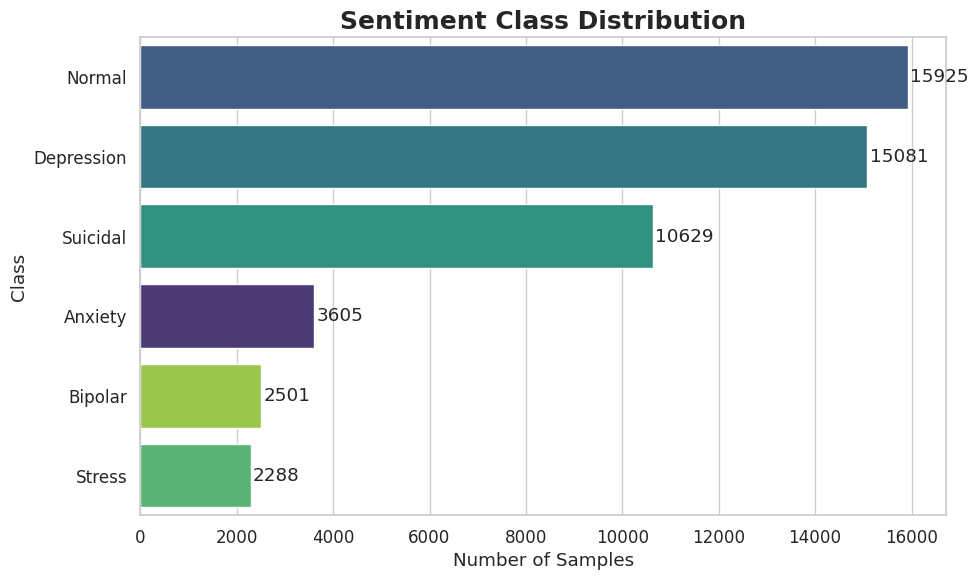

In [32]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    y="status",
    order=df["status"].value_counts().index,
    hue="status",
    palette="viridis",
    legend=False
)

plt.title("Sentiment Class Distribution", fontsize=18, weight="bold")
plt.xlabel("Number of Samples")
plt.ylabel("Class")

# Annotate each bar with its exact sample count
for i, v in enumerate(df["status"].value_counts()):
    ax.text(v + 50, i, str(v), va="center")

plt.tight_layout()
plt.show()


## 8. Text Feature Analysis — Character Length Distribution

Examining the distribution of character length (`char_len`) across all
statements helps identify the typical size of user-generated text, as well
as potential outliers (unusually short or long statements) that may require
special handling during preprocessing or modeling.


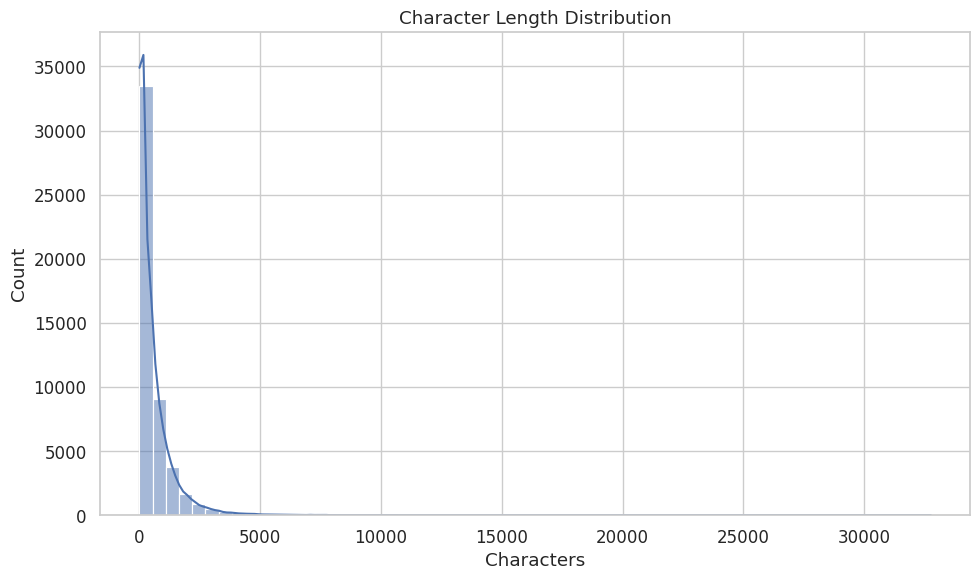

In [33]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["char_len"],
    bins=60,
    kde=True
)

plt.title("Character Length Distribution")
plt.xlabel("Characters")

plt.tight_layout()
plt.show()


## 9. Text Feature Analysis — Word Count Distribution

Similarly, the distribution of word count (`word_len`) provides another
perspective on statement length, which is often more directly comparable
across texts than raw character count and is commonly used as a feature in
NLP pipelines.


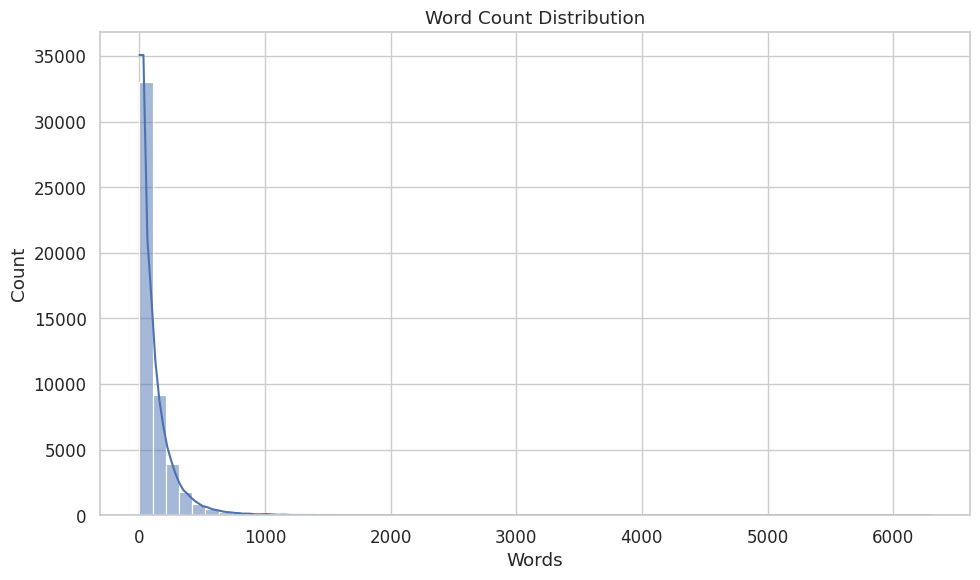

In [34]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["word_len"],
    bins=60,
    kde=True
)

plt.title("Word Count Distribution")
plt.xlabel("Words")

plt.tight_layout()
plt.show()


## 10. Text Length vs. Target — Word Count by Sentiment Class

Comparing word count across sentiment classes helps reveal whether certain
psychological states are associated with longer or shorter statements — a
useful signal for feature engineering and for understanding class-specific
writing behavior.


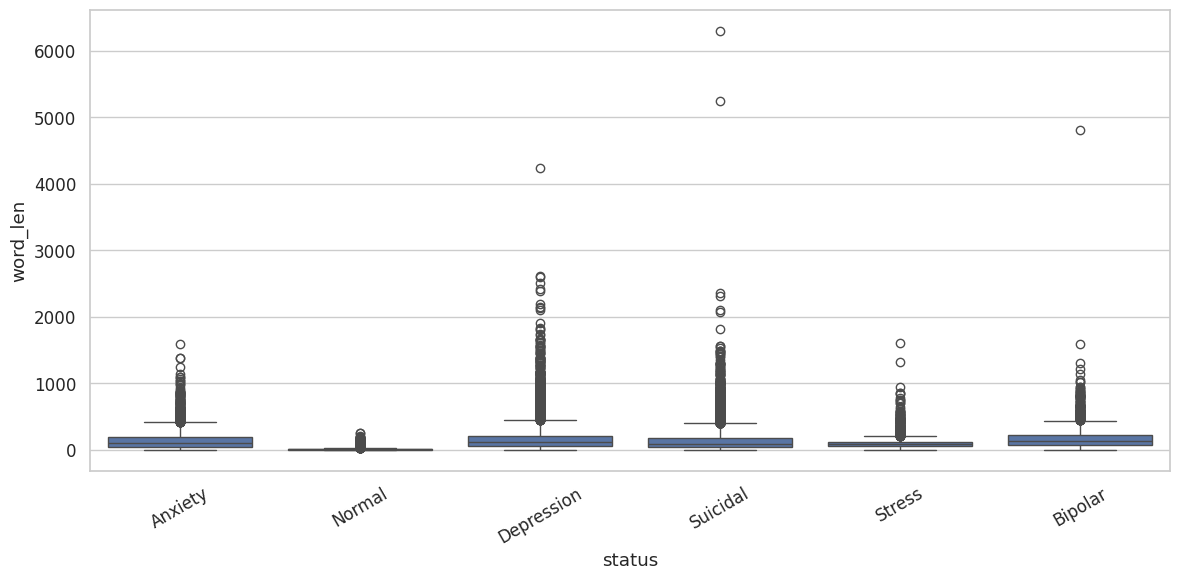

In [35]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="status",
    y="word_len"
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


## 11. Text Length vs. Target — Character Length by Sentiment Class

As a complementary view to the word-count comparison above, we examine
character length across sentiment classes to confirm whether the same
patterns hold at the character level.


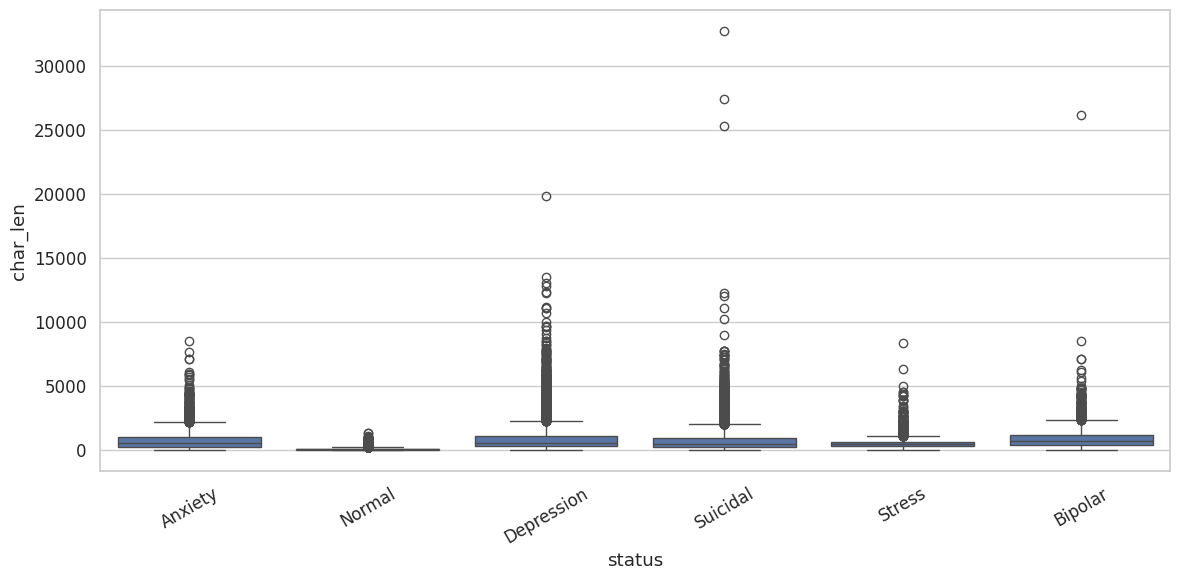

In [36]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="status",
    y="char_len"
)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


## 12. Correlation Analysis — Character Length vs. Word Count

Since `char_len` and `word_len` are both derived from the same text, we
expect them to be strongly correlated. A correlation heatmap quantifies this
relationship and confirms whether one feature could be considered redundant
for modeling purposes.


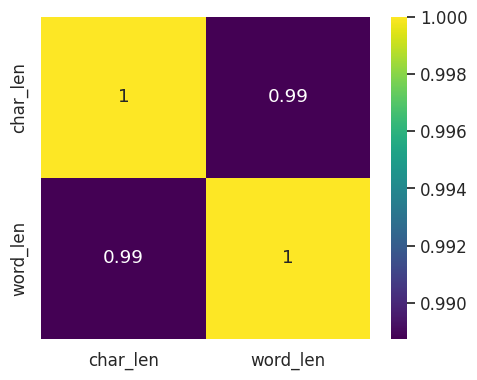

In [37]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    df[["char_len", "word_len"]].corr(),
    annot=True,
    cmap="viridis"
)

plt.tight_layout()
plt.show()


## 13. Vocabulary Analysis — Overall Word Cloud

A word cloud offers a quick, qualitative summary of the most frequent terms
across the entire cleaned corpus (`clean_statement`). Larger words indicate
higher frequency, giving an intuitive sense of the dominant vocabulary used
across all sentiment classes combined.


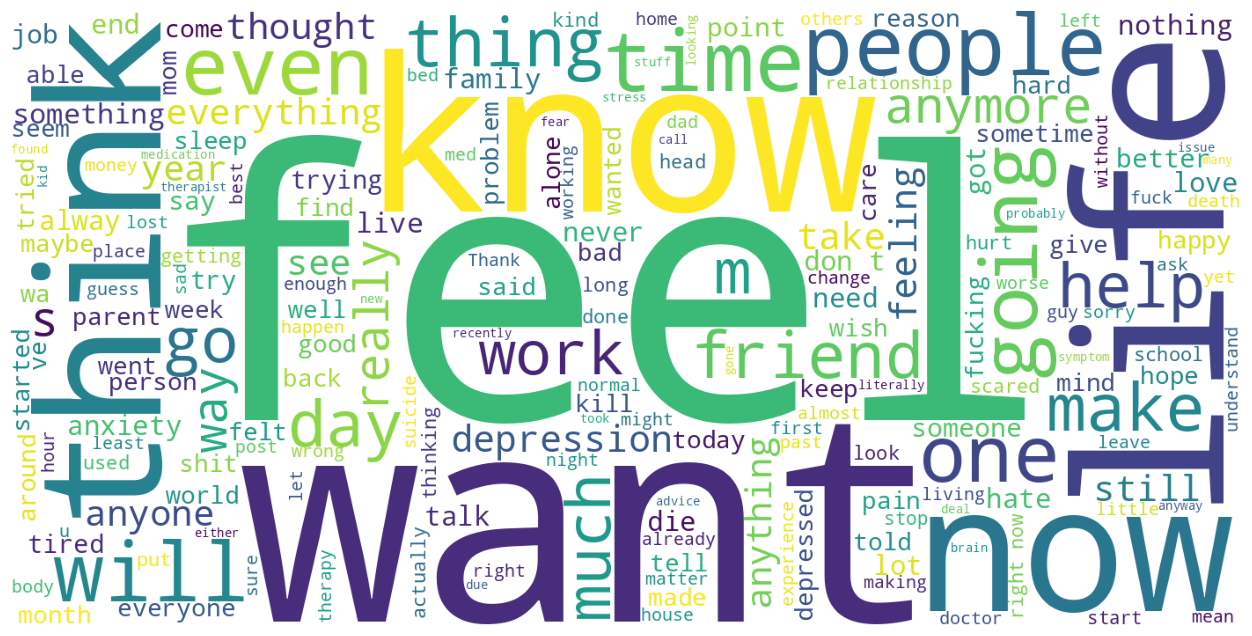

In [38]:
from wordcloud import WordCloud

# Concatenate all cleaned statements into a single text blob
text = " ".join(df["clean_statement"].astype(str))

wc = WordCloud(
    width=1400,
    height=700,
    background_color="white"
).generate(text)

plt.figure(figsize=(16, 8))
plt.imshow(wc)
plt.axis("off")
plt.show()


## 14. Vocabulary Analysis — Word Clouds per Sentiment Class

To understand how vocabulary differs across mental health categories, we
generate a separate word cloud for each class in the `status` column. This
allows for a qualitative, class-specific comparison of dominant words and
themes, which can hint at distinguishing linguistic patterns useful for
downstream classification.


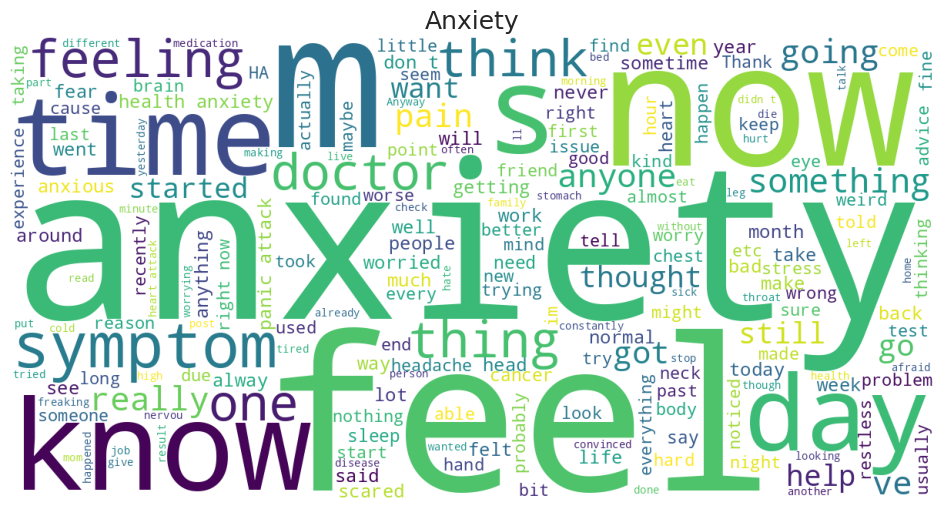

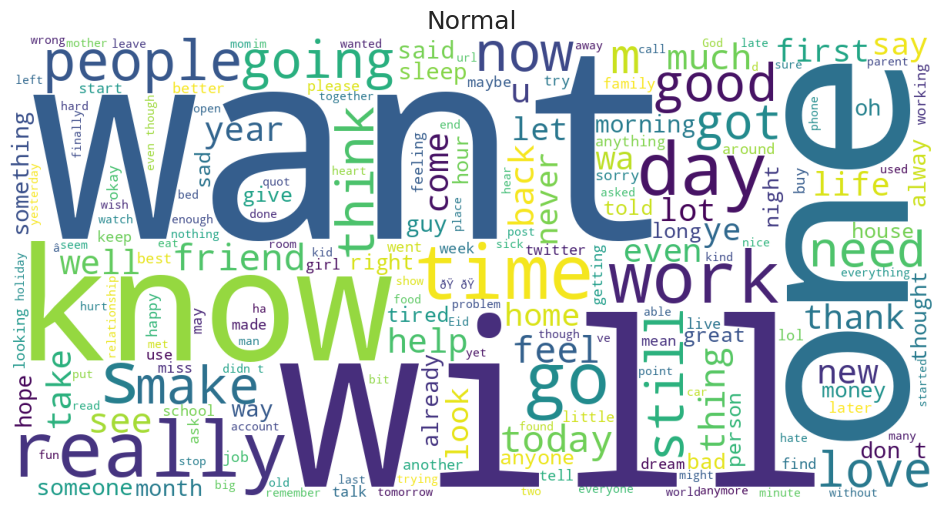

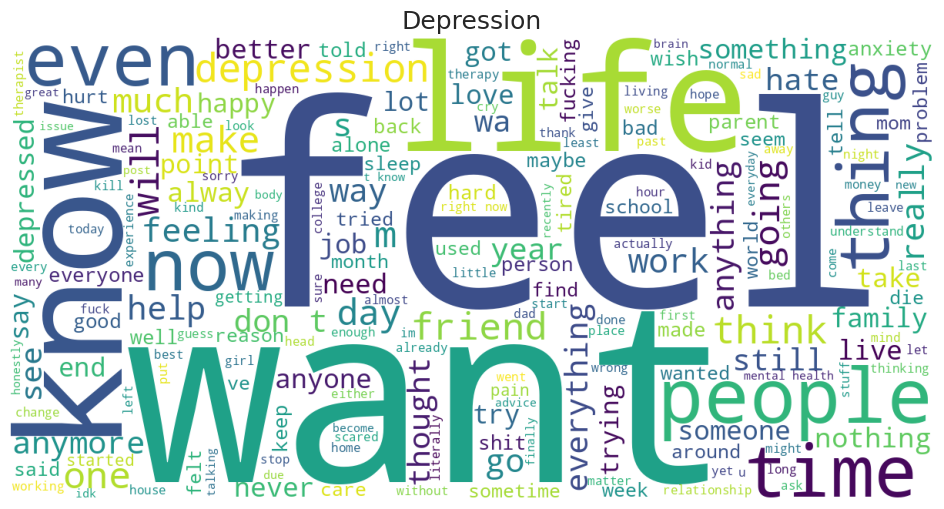

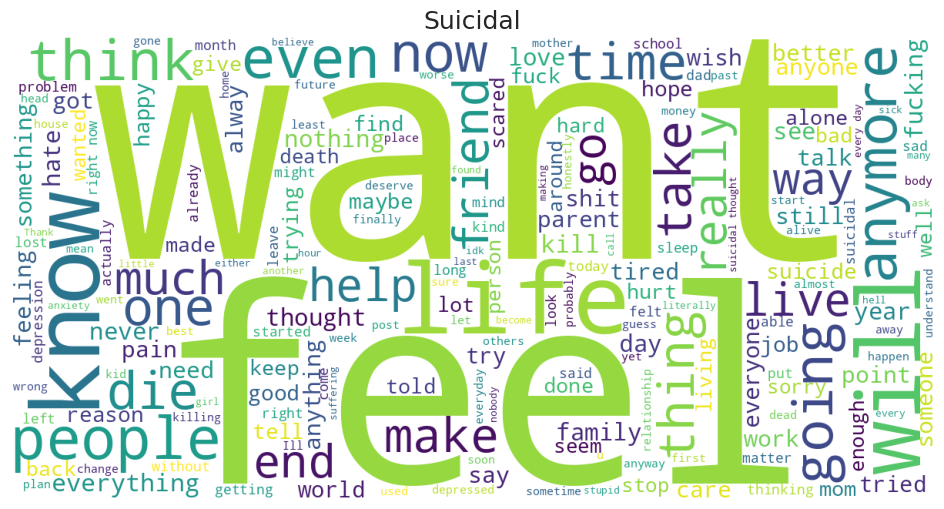

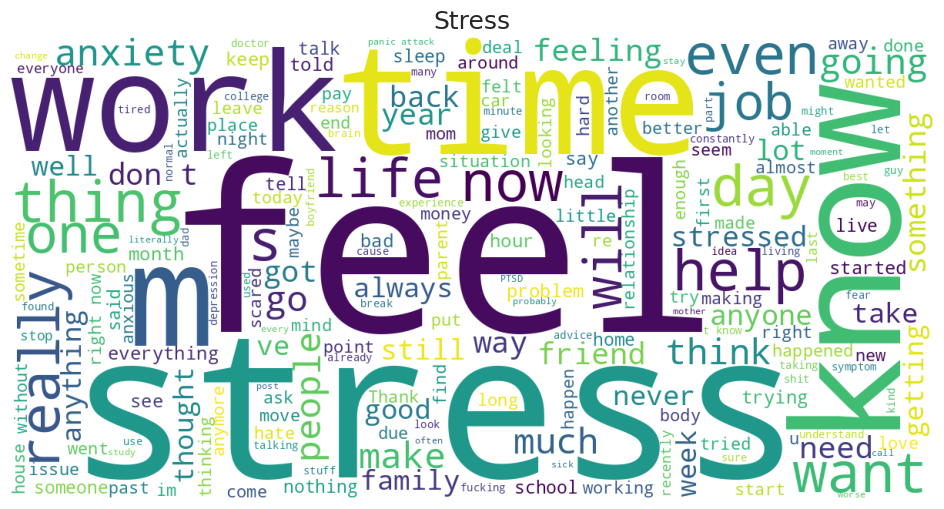

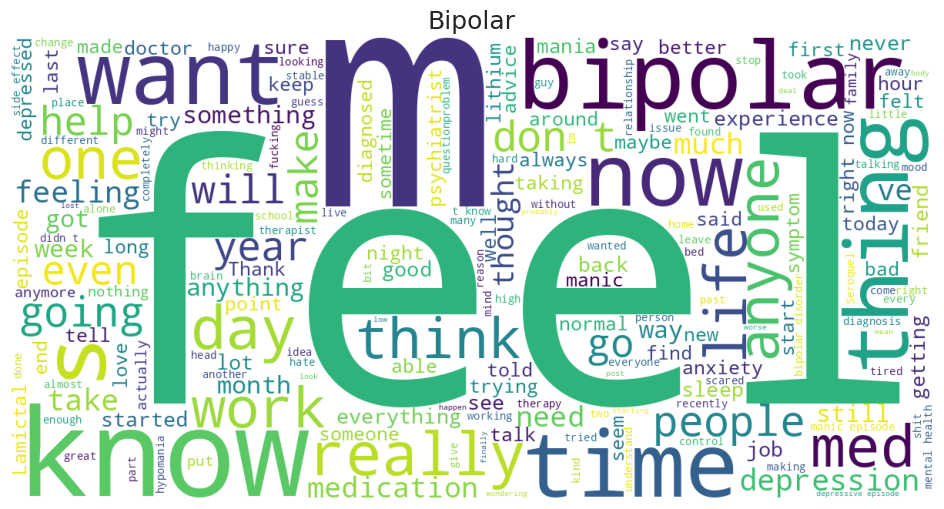

In [39]:
classes = df["status"].unique()

for c in classes:

    # Build the combined text for the current class only
    text = " ".join(
        df[df["status"] == c]["clean_statement"].astype(str)
    )

    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(14, 6))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(c, fontsize=18)
    plt.show()


## Summary

This notebook performed a complete exploratory data analysis of the mental
health sentiment dataset:

- Loaded and cleaned the raw dataset, retaining only valid, well-defined
  sentiment classes.
- Verified data quality (types, missing values, duplicates).
- Examined the target variable distribution and identified class imbalance.
- Analyzed text-length characteristics (`char_len`, `word_len`) globally and
  per sentiment class.
- Quantified the correlation between the two length-based features.
- Generated overall and per-class word clouds to qualitatively explore
  vocabulary patterns.

These findings provide a solid foundation for subsequent feature engineering,
model selection, and evaluation strategy design in the modeling phase of this
project.
